# Week 2 Day 1 — Ridge and Lasso Regularization

## What I built:
- Loaded California Housing dataset (20640 rows, 8 features)
- Split data properly — 70% train, 15% val, 15% test
- Scaled features with StandardScaler (fit on train only)
- Trained LinearRegression, Ridge, and Lasso
- Tuned Ridge alpha across [0.01, 0.1, 1, 10, 100]
- Plotted Val RMSE vs Alpha curve
- Checked which features Lasso zeroed out

## Key concepts learned:

**StandardScaler:**
- Scales each feature to mean=0, std=1
- Always fit on train only — never on val or test
- Fitting on all data = data leakage = fake good scores

**Ridge (L2):**
- Adds penalty λ * Σ(coefficients²) to loss
- Shrinks all coefficients towards zero — never exactly zero
- Best when all features are somewhat useful

**Lasso (L1):**
- Adds penalty λ * Σ|coefficients| to loss  
- Can zero out coefficients completely = feature selection
- Best when you suspect some features are useless

**RMSE:**
- Root Mean Squared Error — average prediction error
- Lower is better (opposite of R²)
- California Housing prices in $100,000 units

## Results:

| Model              | Val RMSE |
|--------------------|----------|
| Linear Regression  | 0.7354   |
| Ridge (alpha=1)    | 0.7354   |
| Lasso (alpha=1)    | 1.1414   |
| Lasso (alpha=0.01) | ~0.7354  |

## Feature zeroed out by Lasso:
- **Population** — least predictive feature for house prices

## Why fit scaler on train only:
In real life you never have future data when training.
Fitting scaler on all data lets it peek at val/test information
— giving unfairly optimistic scores. Always fit on train only.

## Key findings — Regularization

- Ridge alpha=1 gave same RMSE as plain LinearRegression (0.7354)
  → California Housing doesn't overfit much with linear models
  
- Lasso alpha=1 was too aggressive (RMSE=1.14) — zeroed too many features
- Lasso alpha=0.01 zeroed out only Population — makes intuitive sense
  → Population doesn't predict house price as well as other features

- Ridge → shrinks all coefficients, keeps all features
- Lasso → zeroes out weak features automatically (feature selection)

## sklearn Pipeline

**What Pipeline does:**
Chains preprocessing + model into one object.
fit() scales then trains. predict() scales then predicts.
No manual scaling needed, no leakage possible.

**Why Pipeline + cross_val_score is the correct way:**
Without Pipeline — scaler fitted on all folds = data leakage
With Pipeline — scaler fitted only on train folds each time = correct

**Pipeline comparison results:**
- All 3 models similar on California Housing (~0.726 RMSE)
- Regularization helps more on noisy/high-dimensional datasets
- Lasso zeroed out Population feature automatically

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print(df.shape)
print(df.head())
print(df.describe())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%  

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price']).values
y = df['Price'].values

# first split — 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

# second split — split temp into 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train size : {X_train.shape}")
print(f"Val size   : {X_val.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (14448, 8)
Val size   : (3096, 8)
Test size  : (3096, 8)


# StandardScaler - scale every feature so that its mean became 0 and std beacmes 1 and why we do it because Ridge and Lasso penalize large coefficients. Scaling fixes this — all features on same scale, penalty is fair. 
# scaled_value = (value - mean) / std
# fit = learn the mean and std from the data.
# transform = apply (value - mean) / std to every value.
# Data leakage means your model has seen information it shouldn't have — making it look better than it really is in training, but failing in production.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on train — then transform all three
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("Val mean (not exactly 0) :", X_val_scaled.mean(axis=0).round(2))

Train mean (should be ~0): [-0. -0.  0. -0.  0. -0.  0. -0.]
Val mean (not exactly 0) : [-0.02  0.02 -0.03 -0.03  0.   -0.02 -0.06  0.06]


In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# train all 3
lr    = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

lr.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

# evaluate on val
def rmse(model, X, y):
    preds = model.predict(X)                     # get predictions
    return np.sqrt(mean_squared_error(y, preds)) # Calculate rmse

print("=" * 40)
print("   MODEL COMPARISON — VAL RMSE")
print("=" * 40)
print(f"  Linear Regression : {rmse(lr,    X_val_scaled, y_val):.4f}")
print(f"  Ridge (alpha=1)   : {rmse(ridge, X_val_scaled, y_val):.4f}")
print(f"  Lasso (alpha=1)   : {rmse(lasso, X_val_scaled, y_val):.4f}")
print("=" * 40)

   MODEL COMPARISON — VAL RMSE
  Linear Regression : 0.7354
  Ridge (alpha=1)   : 0.7354
  Lasso (alpha=1)   : 1.1414


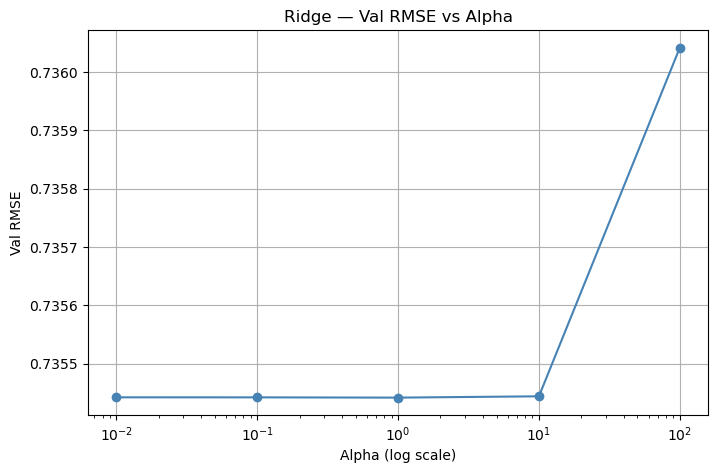

Best alpha : 1
Best RMSE  : 0.7354


In [5]:
import matplotlib.pyplot as plt

alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_scores.append(rmse(ridge, X_val_scaled, y_val))

plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_scores, marker='o', color='steelblue')
plt.xscale('log')   # log scale because alphas vary widely
plt.title('Ridge — Val RMSE vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Val RMSE')
plt.grid(True)
plt.show()

# print best alpha
best_alpha = alphas[np.argmin(ridge_scores)]
print(f"Best alpha : {best_alpha}")
print(f"Best RMSE  : {min(ridge_scores):.4f}")

In [6]:
lasso_best = Lasso(alpha=0.01)   # use small alpha for Lasso
lasso_best.fit(X_train_scaled, y_train)

print("=" * 45)
print("   LASSO COEFFICIENTS")
print("=" * 45)
for feature, coef in zip(housing.feature_names, lasso_best.coef_):
    status = "ZEROED OUT" if coef == 0 else f"{coef:.4f}"
    print(f"  {feature:12} : {status}")
print("=" * 45)
print(f"  Val RMSE : {rmse(lasso_best, X_val_scaled, y_val):.4f}")

   LASSO COEFFICIENTS
  MedInc       : 0.7951
  HouseAge     : 0.1263
  AveRooms     : -0.1618
  AveBedrms    : 0.2091
  Population   : ZEROED OUT
  AveOccup     : -0.0312
  Latitude     : -0.7900
  Longitude    : -0.7570
  Val RMSE : 0.7388


Without Pipeline:
  - You manually scale train, val, test separately
  - Easy to forget, easy to leak data
  - 6+ lines of code per model

With Pipeline:
  - One object handles everything
  - Impossible to leak — scaling happens inside CV automatically
  - 2 lines of code per model

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# build your first pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0))
])

# fit on raw X_train — no manual scaling needed
pipe.fit(X_train, y_train)

# predict on raw X_val — pipeline scales automatically
val_preds = pipe.predict(X_val)

# RMSE
rmse_pipe = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Pipeline RMSE : {rmse_pipe:.4f}")
print(f"Manual RMSE   : 0.7354")
print(f"Match         : {round(rmse_pipe, 4) == 0.7354}")

Pipeline RMSE : 0.7354
Manual RMSE   : 0.7354
Match         : True


In [8]:
from sklearn.model_selection import cross_val_score

# pipeline inside cross_val_score — no leakage possible
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0))
])

scores = cross_val_score(pipe, X_train, y_train, 
                         cv=5, scoring='neg_root_mean_squared_error')

print(f"CV RMSE scores : {-scores.round(4)}")
print(f"Mean RMSE      : {-scores.mean():.4f}")
print(f"Std RMSE       : {scores.std():.4f}")

CV RMSE scores : [0.7402 0.7077 0.7214 0.7184 0.7408]
Mean RMSE      : 0.7257
Std RMSE       : 0.0129


In [9]:
pipelines = {
    'LinearRegression' : Pipeline([('scaler', StandardScaler()),
                                   ('model',  LinearRegression())]),
    'Ridge(alpha=1)'   : Pipeline([('scaler', StandardScaler()),
                                   ('model',  Ridge(alpha=1.0))]),
    'Lasso(alpha=0.01)': Pipeline([('scaler', StandardScaler()),
                                   ('model',  Lasso(alpha=0.01))])
}

print("=" * 45)
print("   PIPELINE COMPARISON — 5-fold CV RMSE")
print("=" * 45)
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5,
                             scoring='neg_root_mean_squared_error')
    print(f"  {name:22} : {-scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 45)

   PIPELINE COMPARISON — 5-fold CV RMSE
  LinearRegression       : 0.7257 ± 0.0129
  Ridge(alpha=1)         : 0.7257 ± 0.0129
  Lasso(alpha=0.01)      : 0.7287 ± 0.0121
